Classificacao de Instrumentos

In [24]:
import librosa
import numpy as np
import os
import re
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

from scipy.signal import convolve2d
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

1. Carregamento

In [30]:
def carregar_audio(caminho_arquivo, sr=22050):
    y, _ = librosa.load(caminho_arquivo, sr=sr)

    # normalizacao de amplitude
    y = y / (np.max(np.abs(y)) + 1e-8)
    return y

# Mapeia instrumentos para labels
CLASSES = {'vio': 0, 'pia': 1, 'cla': 2}
BASE_PATH = Path("datasets")

In [28]:
def plot_spectrum(y, sr, instrumento):
    Y = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), d=1/sr)

    plt.title(f"Espectrograma do {instrumento}")
    plt.plot(freqs, Y)
    plt.xlabel("Frequência (Hz)")
    plt.show()

In [19]:
y_vio = carregar_audio(BASE_PATH / "vio" / "[vio][cla]2095__2.wav")
y_cla = carregar_audio(BASE_PATH / "cla" / "[cla][cla]0150__2.wav")
y_pia = carregar_audio(BASE_PATH / "pia" / "[pia][cla]1283__2.wav")

In [20]:
y_pia

array([ 0.07001851,  0.08726916,  0.05531862, ..., -0.25977692,
       -0.26035088, -0.1610971 ], shape=(66150,), dtype=float32)

Espectogramas dos instrumentos

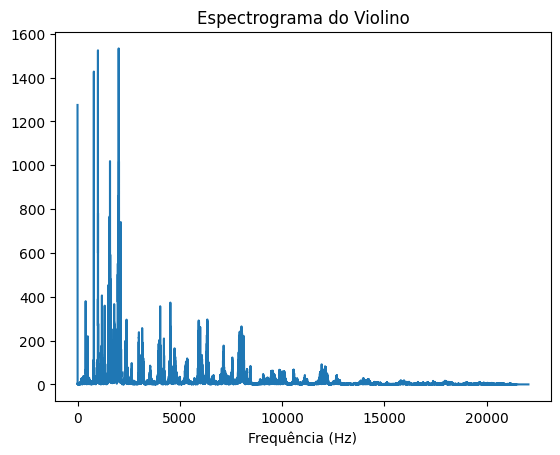

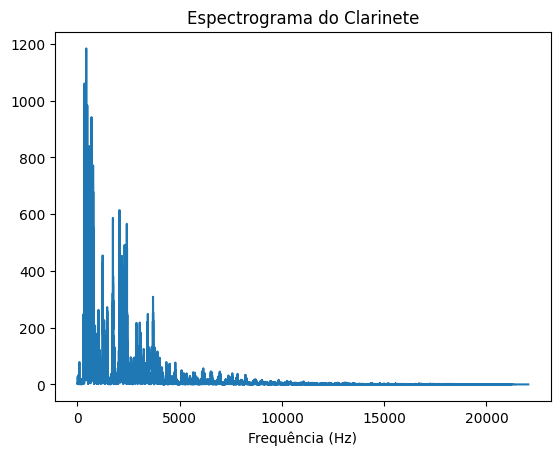

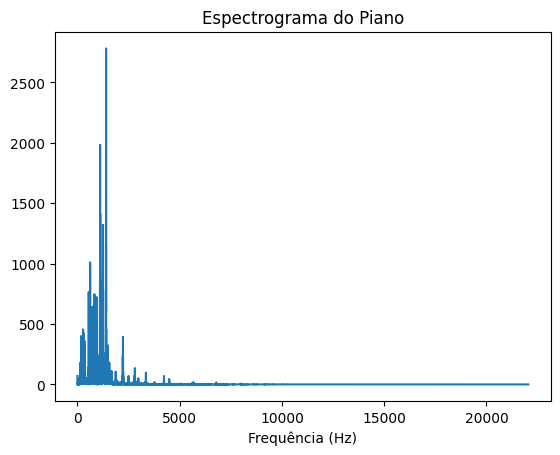

In [29]:
plot_spectrum(y_vio, 44100,instrumento="Violino")
plot_spectrum(y_cla, 44100,instrumento="Clarinete")
plot_spectrum(y_pia, 44100,instrumento="Piano")

Gráfico com frequência e limiares de f_max

piano: 100%|██████████| 721/721 [00:09<00:00, 74.22it/s]


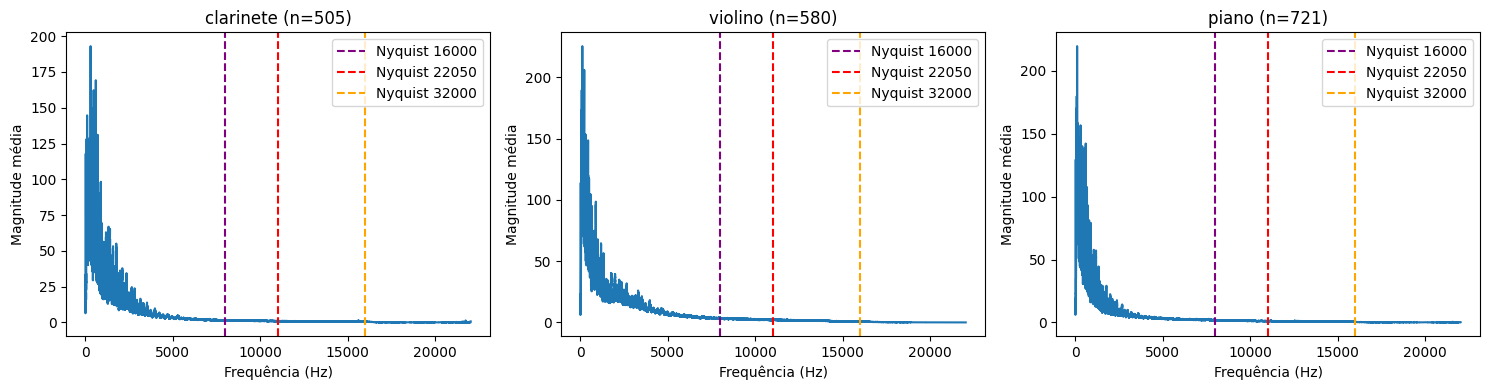

In [15]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

pastas = {
    'clarinete': 'datasets/cla',
    'violino':   'datasets/vio',
    'piano':     'datasets/pia'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, pasta) in zip(axes, pastas.items()):
    arquivos = [f for f in os.listdir(pasta) if f.endswith('.wav')]
    
    espectros = []
    for arquivo in tqdm(arquivos, desc=nome):
        caminho = os.path.join(pasta, arquivo)
        y, sr = librosa.load(caminho, sr=44100, mono=True, duration=3.0)
        Y = np.abs(np.fft.rfft(y))
        espectros.append(Y)
    
    Y_medio = np.mean(espectros, axis=0)
    freqs = np.fft.rfftfreq(len(y), d=1/sr)
    
    ax.plot(freqs, Y_medio)
    ax.axvline(8000, color="purple", linestyle='--', label='Nyquist 16000')
    ax.axvline(11025, color='red',    linestyle='--', label='Nyquist 22050')
    ax.axvline(16000, color='orange', linestyle='--', label='Nyquist 32000')
    ax.set_title(f'{nome} (n={len(arquivos)})')
    ax.set_xlabel('Frequência (Hz)')
    ax.set_ylabel('Magnitude média')
    ax.legend()

plt.tight_layout()
plt.show()

2. Extracao de Features

In [32]:
sr = 22050
fs = 2048   # n_fft
hs = 512    # hop_length
mfcc_dim = 13
ms = 128    # n_mels

def extract_feature(samples):
    result = []
    features = []

    # Timbre features
    spectral_centroid   = librosa.feature.spectral_centroid(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_bandwidth  = librosa.feature.spectral_bandwidth(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_contrast   = librosa.feature.spectral_contrast(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_rolloff    = librosa.feature.spectral_rolloff(y=samples, sr=sr, n_fft=fs, hop_length=hs)
    spectral_flux       = librosa.onset.onset_strength(y=samples, sr=sr, center=True)
    zero_crossing       = librosa.feature.zero_crossing_rate(y=samples, frame_length=fs, hop_length=hs)

    # MFCCs (baseados na DCT — variante da DFT)
    mfcc = librosa.feature.mfcc(y=samples, sr=sr, n_fft=fs, hop_length=hs, n_mfcc=mfcc_dim)

    # Mel-spectrogram (representação 2D — "imagem" do sinal)
    mel_scale = librosa.feature.melspectrogram(y=samples, sr=sr, n_fft=fs, hop_length=hs, n_mels=ms)
    mel_scale = librosa.power_to_db(mel_scale)

    features.append(spectral_centroid)
    features.append(spectral_bandwidth)
    features.append(spectral_contrast)
    features.append(spectral_rolloff)
    features.append(spectral_flux)
    features.append(zero_crossing)

    for feature in features:
        result.append(np.mean(feature))
        result.append(np.std(feature))

    for i in range(mfcc_dim):
        result.append(np.mean(mfcc[i, :]))
        result.append(np.std(mfcc[i, :]))

    return result